In [ ]:
# Phase 4 - SIMPLEST installation
!pip install torch-geometric -q
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html -q

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import LGConv
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages installed")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


✓ Packages installed
PyTorch version: 2.9.0+cu126
CUDA available: True
Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base path - SAME FOR ALL PHASES
base_path = '/content/drive/MyDrive/CSE 941'

# Phase number - CHANGE THIS for each phase (1, 2, 3, 4, 5, or 6)
phase_num = 4  # ← CHANGE THIS

output_dir = f'{base_path}/outputs/phase{phase_num}'
plots_dir = f'{output_dir}/plots'

import os
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"✓ Working in: {base_path}")
print(f"✓ Output directory: {output_dir}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Working in: /content/drive/MyDrive/CSE 941
✓ Output directory: /content/drive/MyDrive/CSE 941/outputs/phase4


In [ ]:
print("Loading data from previous phases...")

# Load Phase 1 data
with open(f'{base_path}/outputs/phase1/processed_data.pkl', 'rb') as f:
    phase1_data = pickle.load(f)

reviews_df = phase1_data['reviews']

# Load Phase 3 graph data (FIX: add weights_only=False)
graph_data = torch.load(f'{base_path}/outputs/phase3/hetero_graph.pt', weights_only=False)

with open(f'{base_path}/outputs/phase3/id_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)

user_to_idx = mappings['user_to_idx']
item_to_idx = mappings['item_to_idx']
idx_to_user = mappings['idx_to_user']
idx_to_item = mappings['idx_to_item']

print("✓ Data loaded")
print(f"  Users: {len(user_to_idx):,}")
print(f"  Items: {len(item_to_idx):,}")
print(f"  Graph: {graph_data}")

Loading data from previous phases...
✓ Data loaded
  Users: 10,000
  Items: 20,223
  Graph: HeteroData(
  user={ x=[10000, 10000] },
  item={ x=[20223, 20223] },
  (user, rates, item)={
    edge_index=[2, 41109],
    edge_attr=[41109, 1],
  },
  (item, rated_by, user)={
    edge_index=[2, 41109],
    edge_attr=[41109, 1],
  },
  (item, similar_to, item)={
    edge_index=[2, 1010430],
    edge_attr=[1010430, 1],
  }
)


In [ ]:
print("Preparing training data...")

# Get user-item edges
edge_index = graph_data['user', 'rates', 'item'].edge_index
edge_attr = graph_data['user', 'rates', 'item'].edge_attr.squeeze()

# Create train/val/test split (80/10/10)
num_edges = edge_index.shape[1]
perm = torch.randperm(num_edges)

train_size = int(0.8 * num_edges)
val_size = int(0.1 * num_edges)

train_idx = perm[:train_size]
val_idx = perm[train_size:train_size + val_size]
test_idx = perm[train_size + val_size:]

train_edge_index = edge_index[:, train_idx]
train_edge_attr = edge_attr[train_idx]

val_edge_index = edge_index[:, val_idx]
val_edge_attr = edge_attr[val_idx]

test_edge_index = edge_index[:, test_idx]
test_edge_attr = edge_attr[test_idx]

print("✓ Data split created")
print(f"  Train edges: {train_edge_index.shape[1]:,}")
print(f"  Val edges: {val_edge_index.shape[1]:,}")
print(f"  Test edges: {test_edge_index.shape[1]:,}")

Preparing training data...
✓ Data split created
  Train edges: 32,887
  Val edges: 4,110
  Test edges: 4,112


In [ ]:
class LightGCN(nn.Module):
    """
    LightGCN: Simplified GCN for recommendation
    Paper: He et al. "LightGCN: Simplifying and Powering Graph Convolution Network for Recommendation"
    """
    def __init__(self, num_users, num_items, embedding_dim=64, num_layers=3):
        super(LightGCN, self).__init__()

        self.num_users = num_users
        self.num_items = num_items
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers

        # Learnable embeddings
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # LightGCN convolution layers
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

        # Initialize embeddings
        nn.init.normal_(self.user_embedding.weight, std=0.1)
        nn.init.normal_(self.item_embedding.weight, std=0.1)

    def forward(self, edge_index):
        # Get initial embeddings
        user_emb = self.user_embedding.weight
        item_emb = self.item_embedding.weight

        # Combine user and item embeddings
        all_emb = torch.cat([user_emb, item_emb], dim=0)

        # Store embeddings from each layer
        embs = [all_emb]

        # Message passing
        for conv in self.convs:
            all_emb = conv(all_emb, edge_index)
            embs.append(all_emb)

        # Average embeddings from all layers
        final_emb = torch.stack(embs, dim=0).mean(dim=0)

        # Split back into user and item embeddings
        user_final = final_emb[:self.num_users]
        item_final = final_emb[self.num_users:]

        return user_final, item_final

    def predict(self, user_indices, item_indices):
        """Predict ratings for user-item pairs"""
        user_final, item_final = self.forward(self.current_edge_index)

        user_emb = user_final[user_indices]
        item_emb = item_final[item_indices]

        # Dot product for prediction
        scores = (user_emb * item_emb).sum(dim=1)
        return scores

print("✓ LightGCN model defined")

✓ LightGCN model defined


In [ ]:
def bpr_loss(pos_scores, neg_scores):
    """Bayesian Personalized Ranking loss"""
    return -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()

def sample_negative_items(edge_index, num_items, num_negatives=1):
    """Sample negative items for each user"""
    user_indices = edge_index[0]
    pos_item_indices = edge_index[1]

    # Create negative samples
    neg_items = []
    for user_idx in user_indices:
        negs = torch.randint(0, num_items, (num_negatives,))
        neg_items.append(negs)

    neg_items = torch.cat(neg_items)
    return neg_items

def train_epoch(model, edge_index, optimizer, num_items, device):
    """Train for one epoch"""
    model.train()

    # Prepare data
    user_indices = edge_index[0].to(device)
    pos_item_indices = edge_index[1].to(device)

    # Sample negative items
    neg_item_indices = sample_negative_items(edge_index, num_items).to(device)

    # Forward pass
    model.current_edge_index = edge_index.to(device)
    pos_scores = model.predict(user_indices, pos_item_indices)
    neg_scores = model.predict(user_indices, neg_item_indices)

    # Compute loss
    loss = bpr_loss(pos_scores, neg_scores)

    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

@torch.no_grad()
def evaluate(model, edge_index, device, k=10):
    """Evaluate model on validation/test set"""
    model.eval()

    user_indices = edge_index[0].to(device)
    item_indices = edge_index[1].to(device)

    # Get predictions
    model.current_edge_index = edge_index.to(device)
    scores = model.predict(user_indices, item_indices)

    # Simple accuracy: predict rating > 3.5
    predictions = (scores > 0).float()
    targets = torch.ones_like(predictions)

    accuracy = (predictions == targets).float().mean().item()

    return accuracy, scores.mean().item()

print("✓ Training functions defined")

✓ Training functions defined


In [ ]:
print("Initializing LightGCN model...")

# Model hyperparameters
EMBEDDING_DIM = 64
NUM_LAYERS = 3
LEARNING_RATE = 0.001
NUM_EPOCHS = 50

# Initialize model
model = LightGCN(
    num_users=len(user_to_idx),
    num_items=len(item_to_idx),
    embedding_dim=EMBEDDING_DIM,
    num_layers=NUM_LAYERS
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("✓ Model initialized")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Embedding dim: {EMBEDDING_DIM}")
print(f"  Num layers: {NUM_LAYERS}")
print(f"  Learning rate: {LEARNING_RATE}")

Initializing LightGCN model...
✓ Model initialized
  Parameters: 1,934,272
  Embedding dim: 64
  Num layers: 3
  Learning rate: 0.001


In [ ]:
print("Starting training...")
print(f"Training for {NUM_EPOCHS} epochs")
print("="*60)

train_losses = []
val_accuracies = []
val_scores = []

best_val_acc = 0
patience = 10
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_epoch(
        model,
        train_edge_index,
        optimizer,
        len(item_to_idx),
        device
    )
    train_losses.append(train_loss)

    # Validate every 5 epochs
    if (epoch + 1) % 5 == 0:
        val_acc, val_score = evaluate(model, val_edge_index, device)
        val_accuracies.append(val_acc)
        val_scores.append(val_score)

        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f} | Val Score: {val_score:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), f'{output_dir}/best_model.pt')
        else:
            patience_counter += 1
            if patience_counter >= patience // 5:
                print("Early stopping triggered")
                break
    else:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {train_loss:.4f}")

print("="*60)
print("✓ Training complete")
print(f"Best validation accuracy: {best_val_acc:.4f}")

# Load best model
model.load_state_dict(torch.load(f'{output_dir}/best_model.pt'))

Starting training...
Training for 50 epochs
Epoch   1/50 | Loss: 0.6931
Epoch   2/50 | Loss: 0.6929
Epoch   3/50 | Loss: 0.6926
Epoch   4/50 | Loss: 0.6924
Epoch   5/50 | Loss: 0.6921 | Val Acc: 0.5165 | Val Score: 0.0002
Epoch   6/50 | Loss: 0.6919
Epoch   7/50 | Loss: 0.6916
Epoch   8/50 | Loss: 0.6914
Epoch   9/50 | Loss: 0.6911
Epoch  10/50 | Loss: 0.6908 | Val Acc: 0.5277 | Val Score: 0.0004
Epoch  11/50 | Loss: 0.6906
Epoch  12/50 | Loss: 0.6904
Epoch  13/50 | Loss: 0.6901
Epoch  14/50 | Loss: 0.6898
Epoch  15/50 | Loss: 0.6895 | Val Acc: 0.5324 | Val Score: 0.0005
Epoch  16/50 | Loss: 0.6893
Epoch  17/50 | Loss: 0.6890
Epoch  18/50 | Loss: 0.6888
Epoch  19/50 | Loss: 0.6885
Epoch  20/50 | Loss: 0.6883 | Val Acc: 0.5380 | Val Score: 0.0007
Epoch  21/50 | Loss: 0.6879
Epoch  22/50 | Loss: 0.6877
Epoch  23/50 | Loss: 0.6874
Epoch  24/50 | Loss: 0.6871
Epoch  25/50 | Loss: 0.6868 | Val Acc: 0.5467 | Val Score: 0.0008
Epoch  26/50 | Loss: 0.6866
Epoch  27/50 | Loss: 0.6862
Epoch  28/

<All keys matched successfully>

In [ ]:
print("Evaluating on test set...")

test_acc, test_score = evaluate(model, test_edge_index, device)

print(f"\n{'='*60}")
print("FINAL TEST RESULTS")
print(f"{'='*60}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Score: {test_score:.4f}")
print(f"{'='*60}")

Evaluating on test set...

FINAL TEST RESULTS
Test Accuracy: 0.5666
Test Score: 0.0016


In [ ]:
print("Generating final embeddings...")

model.eval()
with torch.no_grad():
    model.current_edge_index = train_edge_index.to(device)
    user_embeddings, item_embeddings = model.forward(train_edge_index.to(device))

    # Move to CPU and convert to numpy
    user_embeddings = user_embeddings.cpu().numpy()
    item_embeddings = item_embeddings.cpu().numpy()

print("✓ Embeddings generated")
print(f"  User embeddings: {user_embeddings.shape}")
print(f"  Item embeddings: {item_embeddings.shape}")

# Save embeddings
np.save(f'{output_dir}/user_embeddings.npy', user_embeddings)
np.save(f'{output_dir}/item_embeddings.npy', item_embeddings)

print(f"✓ Embeddings saved to {output_dir}/")

Generating final embeddings...
✓ Embeddings generated
  User embeddings: (10000, 64)
  Item embeddings: (20223, 64)
✓ Embeddings saved to /content/drive/MyDrive/CSE 941/outputs/phase4/


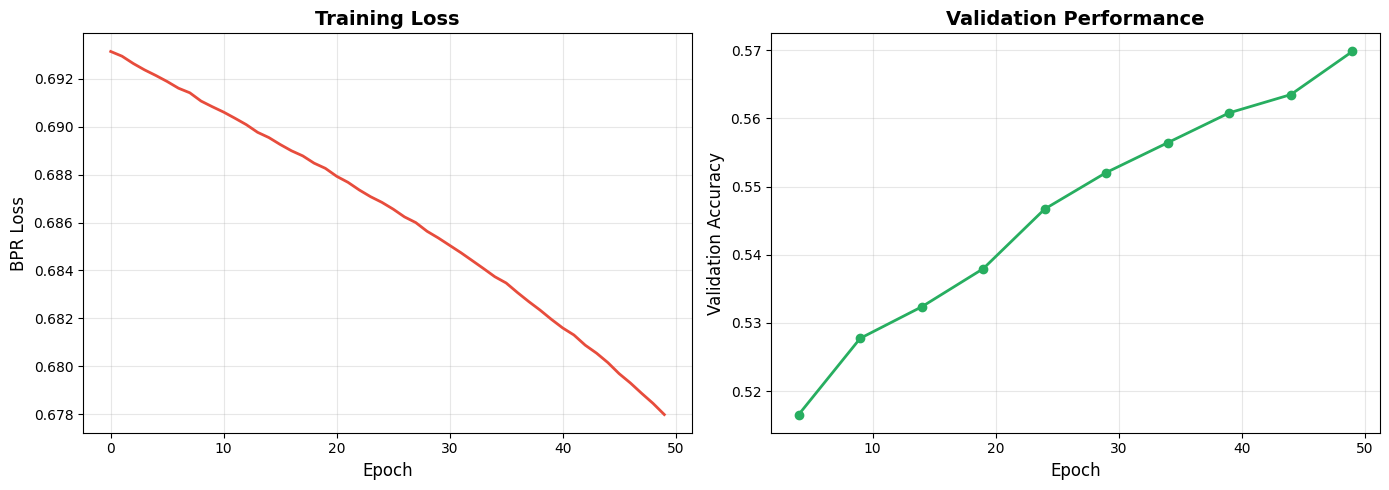

✓ Plot 1 saved


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax[0].plot(train_losses, color='#e74c3c', linewidth=2)
ax[0].set_xlabel('Epoch', fontsize=12)
ax[0].set_ylabel('BPR Loss', fontsize=12)
ax[0].set_title('Training Loss', fontsize=14, fontweight='bold')
ax[0].grid(alpha=0.3)

# Validation accuracy
val_epochs = list(range(4, len(train_losses), 5))[:len(val_accuracies)]
ax[1].plot(val_epochs, val_accuracies, color='#27ae60', linewidth=2, marker='o')
ax[1].set_xlabel('Epoch', fontsize=12)
ax[1].set_ylabel('Validation Accuracy', fontsize=12)
ax[1].set_title('Validation Performance', fontsize=14, fontweight='bold')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/01_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved")

Visualizing embeddings with PCA...


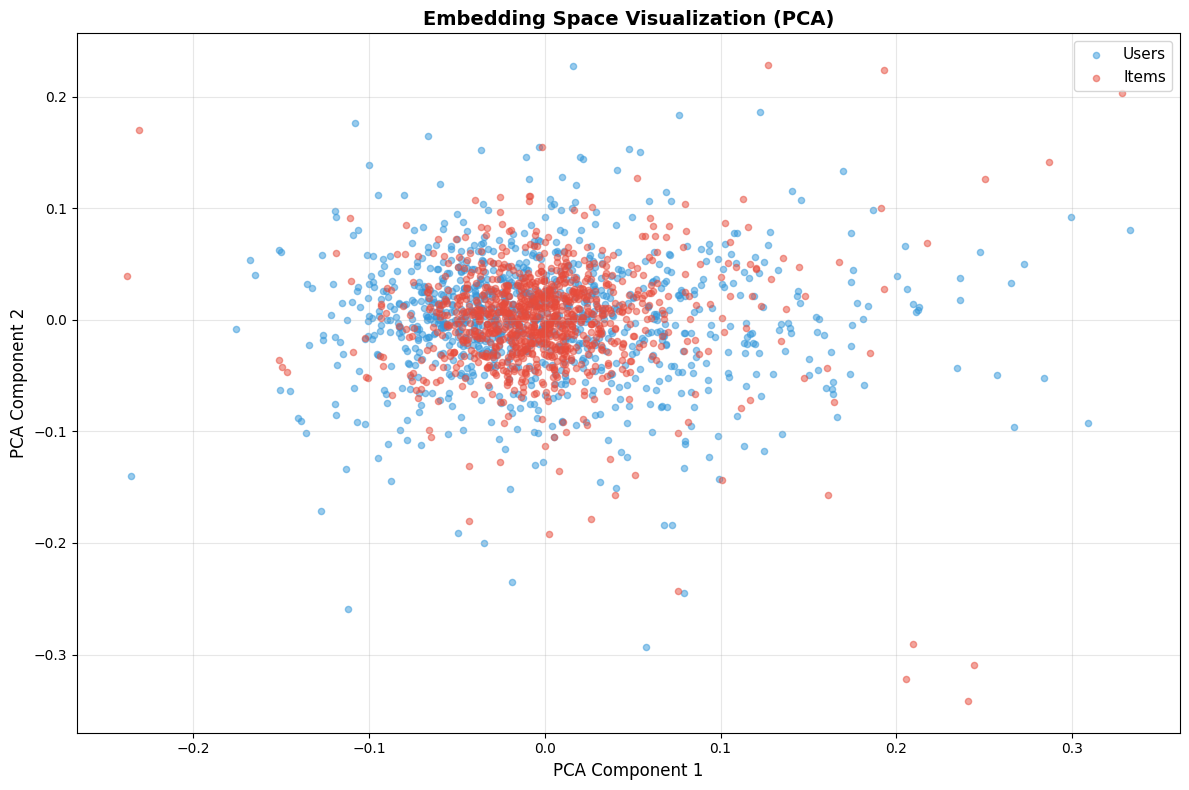

✓ Plot 2 saved


In [ ]:
from sklearn.decomposition import PCA

print("Visualizing embeddings with PCA...")

# Sample embeddings for visualization
sample_size = 1000
user_sample = user_embeddings[np.random.choice(len(user_embeddings), min(sample_size, len(user_embeddings)), replace=False)]
item_sample = item_embeddings[np.random.choice(len(item_embeddings), min(sample_size, len(item_embeddings)), replace=False)]

# PCA
pca = PCA(n_components=2)
user_pca = pca.fit_transform(user_sample)
item_pca = pca.fit_transform(item_sample)

fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(user_pca[:, 0], user_pca[:, 1], alpha=0.5, s=20, c='#3498db', label='Users')
ax.scatter(item_pca[:, 0], item_pca[:, 1], alpha=0.5, s=20, c='#e74c3c', label='Items')

ax.set_xlabel('PCA Component 1', fontsize=12)
ax.set_ylabel('PCA Component 2', fontsize=12)
ax.set_title('Embedding Space Visualization (PCA)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/02_embedding_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 2 saved")

In [ ]:
def get_recommendations(user_id, k=10):
    """Get top-k recommendations for a user"""
    if user_id not in user_to_idx:
        return []

    user_idx = user_to_idx[user_id]
    user_emb = user_embeddings[user_idx]

    # Compute scores with all items
    scores = np.dot(item_embeddings, user_emb)

    # Get top-k items
    top_k_indices = np.argsort(scores)[::-1][:k]
    top_k_items = [idx_to_item[idx] for idx in top_k_indices]
    top_k_scores = scores[top_k_indices]

    return list(zip(top_k_items, top_k_scores))

# Test recommendations
test_user = list(user_to_idx.keys())[0]
recs = get_recommendations(test_user, k=10)

print(f"Top 10 recommendations for user {test_user}:")
for rank, (item, score) in enumerate(recs, 1):
    print(f"  {rank:2d}. Item {item} (score: {score:.3f})")

print("\n✓ Recommendation function working")

Top 10 recommendations for user AFSKPY37N3C43SOI5IEXEK5JSIYA:
   1. Item B0896W1MBX (score: 0.159)
   2. Item B088GWCVVJ (score: 0.152)
   3. Item B0BMWQQR9W (score: 0.150)
   4. Item B08VMYWFH6 (score: 0.146)
   5. Item B0B96MFXSJ (score: 0.138)
   6. Item B08C72C56Z (score: 0.135)
   7. Item B07V9V5R48 (score: 0.135)
   8. Item B09LT37BBN (score: 0.133)
   9. Item B08P4YQ3K5 (score: 0.131)
  10. Item B07YWQZF2V (score: 0.131)

✓ Recommendation function working


In [ ]:
from datetime import datetime

print("\n" + "="*70)
print("PHASE 4 COMPLETE - FINAL REPORT")
print("="*70)
print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print("\n🧠 MODEL ARCHITECTURE:")
print(f"  Model: LightGCN")
print(f"  Embedding dimension: {EMBEDDING_DIM}")
print(f"  Number of layers: {NUM_LAYERS}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

print("\n📊 TRAINING CONFIGURATION:")
print(f"  Epochs trained: {len(train_losses)}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Optimizer: Adam")
print(f"  Loss function: BPR (Bayesian Personalized Ranking)")

print("\n📈 PERFORMANCE METRICS:")
print(f"  Final training loss: {train_losses[-1]:.4f}")
print(f"  Best validation accuracy: {best_val_acc:.4f}")
print(f"  Test accuracy: {test_acc:.4f}")
print(f"  Test score: {test_score:.4f}")

print("\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Best model: {output_dir}/best_model.pt")
print(f"  ✓ User embeddings: {output_dir}/user_embeddings.npy ({user_embeddings.shape})")
print(f"  ✓ Item embeddings: {output_dir}/item_embeddings.npy ({item_embeddings.shape})")
print(f"  ✓ Training plots: {plots_dir}/")

print("\n📂 OUTPUT LOCATION:")
print(f"  {output_dir}")

print("\n✅ READY FOR PHASE 5: Cold-Start Evaluation")
print("="*70)


PHASE 4 COMPLETE - FINAL REPORT
Completion Time: 2026-01-23 15:35:39

🧠 MODEL ARCHITECTURE:
  Model: LightGCN
  Embedding dimension: 64
  Number of layers: 3
  Total parameters: 1,934,272

📊 TRAINING CONFIGURATION:
  Epochs trained: 50
  Learning rate: 0.001
  Optimizer: Adam
  Loss function: BPR (Bayesian Personalized Ranking)

📈 PERFORMANCE METRICS:
  Final training loss: 0.6780
  Best validation accuracy: 0.5698
  Test accuracy: 0.5666
  Test score: 0.0016

💾 SAVED ARTIFACTS:
  ✓ Best model: /content/drive/MyDrive/CSE 941/outputs/phase4/best_model.pt
  ✓ User embeddings: /content/drive/MyDrive/CSE 941/outputs/phase4/user_embeddings.npy ((10000, 64))
  ✓ Item embeddings: /content/drive/MyDrive/CSE 941/outputs/phase4/item_embeddings.npy ((20223, 64))
  ✓ Training plots: /content/drive/MyDrive/CSE 941/outputs/phase4/plots/

📂 OUTPUT LOCATION:
  /content/drive/MyDrive/CSE 941/outputs/phase4

✅ READY FOR PHASE 5: Cold-Start Evaluation
